# Experiment 04 — Circuit Depth Variations

**Research question:** How does increasing the number of variational layers affect VQC classification performance?

**Setup:** Fixed 2 features (cols 26, 4), 5000 samples, angle encoding.  
We vary the number of model layers: **1 → 2 → 3 → 4**.

### What to watch for
- More layers = more parameters = more expressive circuit
- But deeper circuits risk **barren plateaus** (vanishing gradients) and overfitting
- The paper uses 2 layers; do we gain anything by going deeper?

| Layers | Params (2 qubits) |
|--------|-------------------|
| 1 | 1×2×3 + 1 = 7 |
| 2 | 2×2×3 + 1 = 13 |
| 3 | 3×2×3 + 1 = 19 |
| 4 | 4×2×3 + 1 = 25 |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score, roc_curve

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

## 1. Setup

In [2]:
# Hyperparameters — all fixed except N_LAYERS
N_FEATURES = 2
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01
N_SAMPLES  = 5000

LAYER_COUNTS = [1, 2, 3, 4]

# Load data once (same split for all depth experiments)
X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
    path='../data/HIGGS.csv.gz',
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    feature_indices=[26, 4],
    scale_range=(0, np.pi),
)

Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000


## 2. Circuit and Training

In [3]:
def build_circuit(n_features, n_layers):
    """Build a VQC circuit with configurable depth."""
    dev = qml.device('default.qubit', wires=n_features)

    @qml.qnode(dev, interface='autograd')
    def circuit(weights, x):
        # State preparation: angle encoding
        for i in range(n_features):
            qml.RY(x[i], wires=i)
        # Model circuit: L layers
        for l in range(n_layers):
            for q in range(n_features):
                qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
            qml.CNOT(wires=[0, 1])
            qml.CNOT(wires=[1, 0])
        return qml.expval(qml.PauliZ(0))

    return circuit


def train_vqc(circuit_fn, X_train, y_train, X_val, y_val,
              n_layers, n_features, n_epochs, batch_size, lr):
    """Train VQC and return weights, bias, loss histories."""
    weights = pnp.array(
        np.random.uniform(0, 2*np.pi, (n_layers, n_features, 3)),
        requires_grad=True
    )
    bias = pnp.array(0.0, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=lr)

    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        perm = np.random.permutation(len(X_train))
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, len(X_train), batch_size):
            Xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size].astype(float)

            def cost(w, b):
                preds = pnp.array([circuit_fn(w, x) + b for x in Xb])
                return pnp.mean((yb - preds) ** 2)

            weights, bias = opt.step(cost, weights, bias)

        # Epoch-level metrics
        tr_preds = pnp.array([circuit_fn(weights, x) + bias for x in X_train])
        vl_preds = pnp.array([circuit_fn(weights, x) + bias for x in X_val])
        tr_loss = float(pnp.mean((y_train.astype(float) - tr_preds)**2))
        vl_loss = float(pnp.mean((y_val.astype(float) - vl_preds)**2))
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1}/{n_epochs} | '
                  f'train_loss={tr_loss:.4f}, val_loss={vl_loss:.4f}')

    return weights, bias, train_losses, val_losses

## 3. Run Depth Experiments

In [4]:
results = {}

for n_layers in LAYER_COUNTS:
    n_params = n_layers * N_FEATURES * 3 + 1
    print(f'\n{"="*50}')
    print(f'Running: {n_layers} layers ({n_params} params)')

    circuit_fn = build_circuit(N_FEATURES, n_layers)

    np.random.seed(42)
    weights, bias, tr_loss, vl_loss = train_vqc(
        circuit_fn, X_train, y_train, X_val, y_val,
        n_layers, N_FEATURES, N_EPOCHS, BATCH_SIZE, LR
    )

    # Test evaluation
    test_raw = np.array([float(circuit_fn(weights, x) + bias) for x in X_test])
    test_acc = binary_accuracy(y_test, test_raw)
    y_test_01 = (y_test == 1).astype(int)
    test_score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
    test_auc = roc_auc_score(y_test_01, test_score)

    results[n_layers] = {
        'train_losses': tr_loss,
        'val_losses': vl_loss,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'test_scores': test_score,
        'n_params': n_params,
    }
    print(f'  → Test acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}')


Running: 1 layers (7 params)
  Epoch 1/30 | train_loss=0.9966, val_loss=0.9966
  Epoch 10/30 | train_loss=0.9845, val_loss=0.9880
  Epoch 20/30 | train_loss=0.9858, val_loss=0.9901
  Epoch 30/30 | train_loss=0.9843, val_loss=0.9881
  → Test acc: 0.5630 | Test AUC: 0.5390

Running: 2 layers (13 params)
  Epoch 1/30 | train_loss=0.9669, val_loss=0.9665
  Epoch 10/30 | train_loss=0.9522, val_loss=0.9529
  Epoch 20/30 | train_loss=0.9499, val_loss=0.9525
  Epoch 30/30 | train_loss=0.9496, val_loss=0.9526
  → Test acc: 0.6160 | Test AUC: 0.6087

Running: 3 layers (19 params)
  Epoch 1/30 | train_loss=0.9661, val_loss=0.9687
  Epoch 10/30 | train_loss=0.9563, val_loss=0.9627
  Epoch 20/30 | train_loss=0.9544, val_loss=0.9613
  Epoch 30/30 | train_loss=0.9499, val_loss=0.9548
  → Test acc: 0.6040 | Test AUC: 0.6151

Running: 4 layers (25 params)
  Epoch 1/30 | train_loss=0.9812, val_loss=0.9735
  Epoch 10/30 | train_loss=0.9557, val_loss=0.9587
  Epoch 20/30 | train_loss=0.9549, val_loss=0.9

## 4. Results

In [5]:
print('\nCircuit Depth Results')
print(f'{"Layers":>8} {"Params":>8} {"Test Acc":>10} {"Test AUC":>10}')
print('-' * 40)
for nl, r in results.items():
    print(f'{nl:>8} {r["n_params"]:>8} {r["test_acc"]:>10.4f} {r["test_auc"]:>10.4f}')


Circuit Depth Results
  Layers   Params   Test Acc   Test AUC
----------------------------------------
       1        7     0.5630     0.5390
       2       13     0.6160     0.6087
       3       19     0.6040     0.6151
       4       25     0.6120     0.6146


## 5. Plots

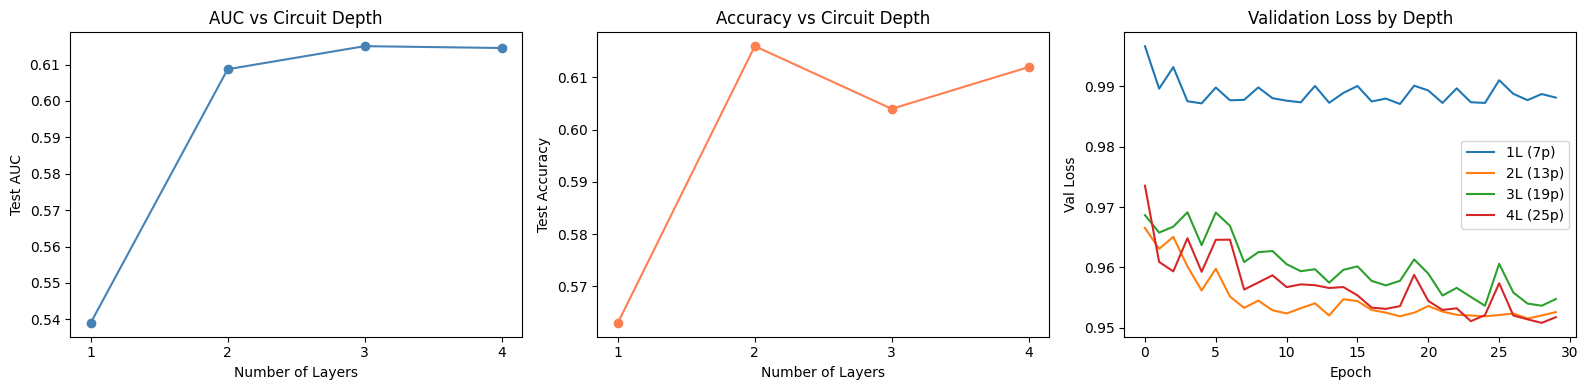

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

layers = list(results.keys())
aucs = [results[l]['test_auc'] for l in layers]
accs = [results[l]['test_acc'] for l in layers]

# AUC vs depth
axes[0].plot(layers, aucs, 'o-', color='steelblue')
axes[0].set_xlabel('Number of Layers')
axes[0].set_ylabel('Test AUC')
axes[0].set_title('AUC vs Circuit Depth')
axes[0].set_xticks(layers)

# Accuracy vs depth
axes[1].plot(layers, accs, 'o-', color='coral')
axes[1].set_xlabel('Number of Layers')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Accuracy vs Circuit Depth')
axes[1].set_xticks(layers)

# Training curves overlay
for nl, r in results.items():
    axes[2].plot(r['val_losses'], label=f'{nl}L ({r["n_params"]}p)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val Loss')
axes[2].set_title('Validation Loss by Depth')
axes[2].legend()

plt.tight_layout()
plt.savefig('../figures/04_circuit_depth.png', dpi=150)
plt.show()

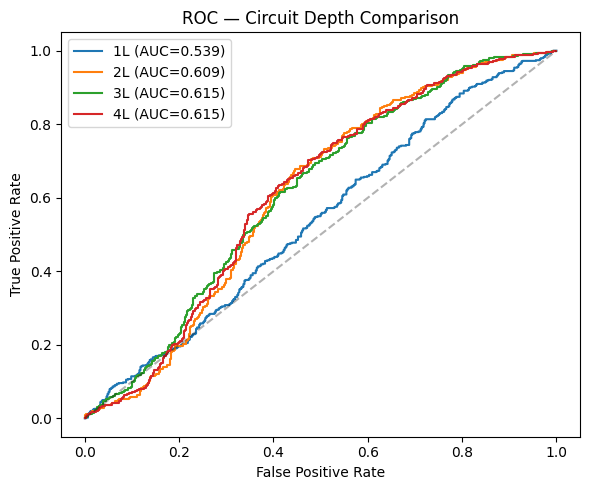

In [7]:
plt.figure(figsize=(6, 5))
y_test_01 = (y_test == 1).astype(int)

for nl, r in results.items():
    fpr, tpr, _ = roc_curve(y_test_01, r['test_scores'])
    plt.plot(fpr, tpr, label=f'{nl}L (AUC={r["test_auc"]:.3f})')

plt.plot([0,1],[0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — Circuit Depth Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/04_roc_depth.png', dpi=150)
plt.show()

## Observations

*(Fill in after running)*

- Does AUC improve with depth, or plateau / degrade?
- Is there a train-val gap that grows with depth (overfitting)?
- Does the 1-layer circuit underperform significantly (underfitting)?
- At what depth (if any) do we see signs of barren plateaus (slow/stuck training)?
- How does the best depth compare to the 2-layer paper baseline?